## Завдання 1 та 2 рівня складності
### Група вимог_1:
1. Отримати вхідні дані із властивостями, заданими в Лр_1: реальні та / або
синтетичні;
2. Провести дослідження вхідних даних та за наявності аномалій застосувати
алгоритми їх компенсації.
3. Реалізувати рекурентне згладжування вхідних даних з використанням алгоритмів
фільтрації Калмана (alfa-beta, alfa-beta-gamma фільтри).
4. Фільтр має давати незміщену оцінку.
5. Вибір фільтра обгрунтувати.
Аналіз та обробка часових рядів (Time Series)
(Сертифікатна програма Data Science із Sigma Software)

### Група вимог_2:
1. Модифікувати скалярний фільтр, що залучений для реалізації функціоналу групи
вимог_1 у одному з напрямків:
адаптація параметрів / «пам’яті» фільтра для усунення ефекту розходження;
підвищити ступінь фільтра для подолання ефекту розходження;
розробити алгоритм адаптивної модифікації рекурентного фільтра для подолання
ефекту розходження.
УВАГА! Рішення у емпірично підібраних константах в параметрах фільтрів лише для
конкретної структури вхідних даних не вважається ефективним.

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
import filterpy
import torch
from sklearn.preprocessing import StandardScaler
import statsmodels.tsa.seasonal as seas
import statsmodels.api as sm
from bs4 import BeautifulSoup
from pathlib import Path

In [272]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df_full = df[(df['Date'] > '2021-12-31') & (df['Date'] < '2024-12-31')].reset_index(drop=True)
df_full[['Buy', 'Sell']] = df_full[['Buy', 'Sell']].astype(float)
df_1 = df[(df['Date'] > '2021-12-31') & (df['Date'] < '2024-02-15')].reset_index(drop=True)
df_1[['Buy', 'Sell']] = df_1[['Buy', 'Sell']].astype(float)
df = df[(df['Date'] > '2021-12-31') & (df['Date'] < '2023-10-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

df

,Date,Buy,Sell
0,2022-01-04,30.9125,30.9350
1,2022-01-05,31.1202,31.1429
2,2022-01-06,31.1298,31.1524
3,2022-01-10,31.0725,31.0923
4,2022-01-11,31.2710,31.2909
...,...,...,...
367,2023-10-24,38.7905,38.8044
368,2023-10-25,38.6666,38.6731
369,2023-10-26,38.4722,38.4933
370,2023-10-27,38.5290,38.5465


In [273]:
print(len(df), len(df_1), len(df_full))

372 449 677


In [274]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


In [275]:
def clean_anomalies(df, column='Buy', window=10, sigma=3):
    # Cleaning out anomalies function by mean and std
    df_clean = df.copy()
    rolling_mean = df_clean[column].rolling(window=window).mean()
    rolling_std = df_clean[column].rolling(window=window).std()

    upper_bond = rolling_mean + (sigma * rolling_std)
    lower_bond = rolling_mean - (sigma * rolling_std)

    anomalies = df_clean[(df_clean[column] > upper_bond) | (df_clean[column] < lower_bond)]

    df_clean.loc[anomalies.index, column] = np.nan
    df_clean[column] = df_clean[column].interpolate(method='polynomial', order=5)

    return df_clean, anomalies

def clean_anomalies_by_volatility(df, column='Buy', sigma=3):
    # Cleaning out anomalies function percentage change
    df_clean = df.copy()
    df_clean['returns'] = df_clean[column].pct_change()

    returns_mean = df_clean['returns'].mean()
    returns_std = df_clean['returns'].std()

    upper_threshold = returns_mean + (sigma * returns_std)
    lower_threshold = returns_mean - (sigma * returns_std)

    anomaly_mask = (df_clean['returns'] > upper_threshold) | (df_clean['returns'] < lower_threshold)
    anomalies = df_clean[anomaly_mask]

    df_clean.loc[anomaly_mask, column] = np.nan
    df_clean[column] = df_clean[column].interpolate(method='polynomial', order=5)

    return df_clean.drop(columns=['returns']), anomalies

def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')

def models_resid_verification(dtf, resid_real, resid_synthetic):
    # Function for models resid verification from previous laboratorium(maybe will be useful in future)
    print(dtf[['Synthetic_Buy', 'Buy']].describe())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))

    ax[0].hist(resid_real, label="Real", edgecolor='black')
    ax[0].set_xlabel('Resid of the real data')
    ax[0].legend(loc="best")

    ax[1].hist(resid_synthetic, label="Synthetic", edgecolor='black')
    ax[1].set_xlabel('Resid of the synthetic data')
    ax[1].legend(loc="best")
    plt.show()

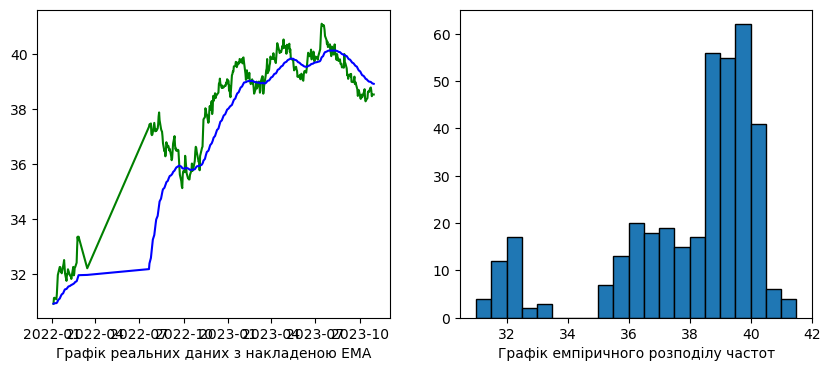

In [276]:
# Got anomalies data, but since it's currency price for buy/sell - there will be no major anomalies, which will be the reason to continue laboratorium with my main dataframe - df
df_clean, anomalies_buy = clean_anomalies(df, 'Buy')
df_clean, anomalies_sell = clean_anomalies(df_clean, 'Sell')
draw_plots(df, 'Date', 'Buy')

In [277]:
print('Anomalies: ')
anomalies_buy[['Date', 'Buy']].join(anomalies_sell[['Sell']], lsuffix='_buy', rsuffix='_sell', how='left')

Anomalies: 


,Date,Buy,Sell


In [278]:
df_clean_1, anomalies_buy = clean_anomalies_by_volatility(df, 'Buy')
df_clean_1, anomalies_sell = clean_anomalies_by_volatility(df_clean_1, 'Sell')

In [279]:
print('Anomalies by volatility: ')
# pd.concat([anomalies_buy.drop('Sell', axis=1), anomalies_sell.drop('Buy', axis=1)])
# pd.concat([anomalies_buy, anomalies_sell])
anomalies_buy[['Date', 'Buy', 'returns']].join(anomalies_sell[['Sell', 'returns']], lsuffix='_buy', rsuffix='_sell', how='left')

Anomalies by volatility: 


,Date,Buy,returns_buy,Sell,returns_sell
38,2022-03-15,32.2042,-0.034531,32.5345,-0.047005
39,2022-07-21,37.3584,0.160047,37.7320,0.159753


In [280]:
# Main filter class
class AlphaBetaGammaFilter:
    def __init__(self, alpha=0.25, beta=0.005, gamma=0.001,
                 initial_value=None, initial_velocity=0, initial_accel=0,
                 adaptive=False):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        self.x = initial_value
        self.v = initial_velocity
        self.a = initial_accel

        self.adaptive = adaptive
        self.estimates = []

    def my_sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def update(self, measurement, dt=1):
        if self.x is None:
            self.x = measurement
            self.estimates.append(self.x)
            return self.x

        x_pred = self.x + self.v * dt + 0.5 * self.a * (dt ** 2)
        v_pred = self.v + self.a * dt
        a_pred = self.a

        residual = measurement - x_pred

        if self.adaptive:
            min_alpha = 0.1
            max_alpha = 0.5
            center = 0.5
            slope = 2

            sigmoid_input = (abs(residual) - center) * slope
            self.alpha = min_alpha + (max_alpha - min_alpha) * self.my_sigmoid(sigmoid_input)
            self.beta = 2 * (2 - self.alpha) - 4 * np.sqrt(1 - self.alpha)
            self.gamma = (self.beta ** 2) / (2 - self.alpha)

        self.x = x_pred + self.alpha * residual
        self.v = v_pred + self.beta / dt * residual
        self.a = a_pred + (2 * self.gamma) / (dt ** 2) * residual

        self.estimates.append(self.x)
        return self.x

    def extrapolate(self, steps, dt=1):
        extrapol_results = []
        temp_x = self.x
        temp_v = self.v
        temp_a = self.a

        for i in range(steps):
            temp_x = temp_x + temp_v * dt + 0.5 * temp_a * (dt ** 2)
            temp_v = temp_v + temp_a * dt
            extrapol_results.append(temp_x)

        return np.array(extrapol_results)

In [281]:
# Normality of data
scaler = StandardScaler()
scaler.fit(df[['Buy']])

norm_df = df.copy().drop('Sell', axis=1)
norm_df[['Buy']] = scaler.transform(df[['Buy']])
filter_1 = AlphaBetaGammaFilter(alpha=0.25, beta=0.005, gamma=0.001,
                 initial_value=None, initial_velocity=0, initial_accel=0,
                 adaptive=True)

In [282]:
def main_filter_process(filter, custom_norm_df, col_name, steps_num=5):
    # Going through the data
    filtered_data = []
    for price in custom_norm_df[col_name].values:
        filtered_data.append(filter.update(price))

    # Extrapolation process
    extrapol_results = filter.extrapolate(steps=steps_num)
    return np.concatenate((np.array(filtered_data), extrapol_results), axis=None)

In [283]:
concatenated_result = main_filter_process(filter_1, norm_df, 'Buy', 50)
print(len(concatenated_result))

422


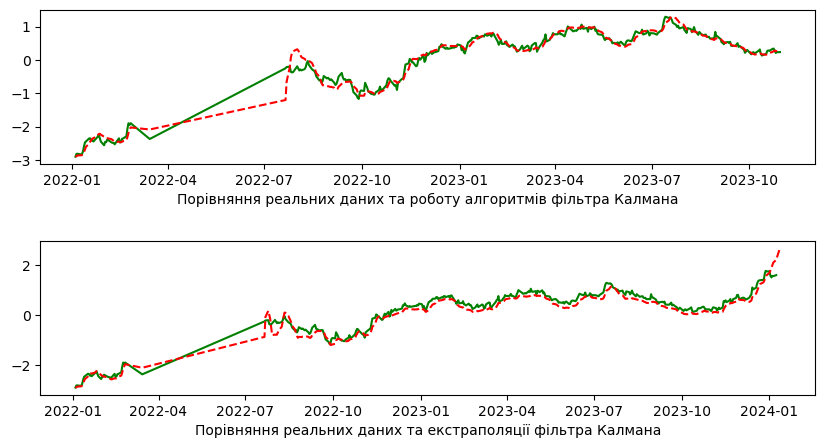

In [288]:
# Normality of 'full dataset', which contains information about the last days data, so we will be able to compare extrapolation results
norm_full_df = df_full.copy().drop('Sell', axis=1)
norm_full_df['Buy'] = scaler.transform(norm_full_df[['Buy']])

# Comparing results of filter's "going through" process and extrapolation process
fig, ax = plt.subplots(nrows=2, figsize=(10, 5))
ax[0].plot(norm_df['Date'], norm_df['Buy'], label='Реальні дані', color='g')
ax[0].plot(norm_df['Date'], concatenated_result[:len(norm_df)], color='r', linestyle='--')
ax[0].set_xlabel('Порівняння реальних даних та роботу алгоритмів фільтра Калмана')

ax[1].plot(norm_full_df['Date'].iloc[:len(concatenated_result)], norm_full_df['Buy'].iloc[:len(concatenated_result)], label='Реальні дані', color='g')
ax[1].plot(norm_full_df['Date'].iloc[:len(normed_concatenated_result)], normed_concatenated_result, label='екстраполяція фільтра Калмана', color='r', linestyle='--')
ax[1].set_xlabel('Порівняння реальних даних та екстраполяції фільтра Калмана')

plt.subplots_adjust(hspace=0.5)
plt.show()

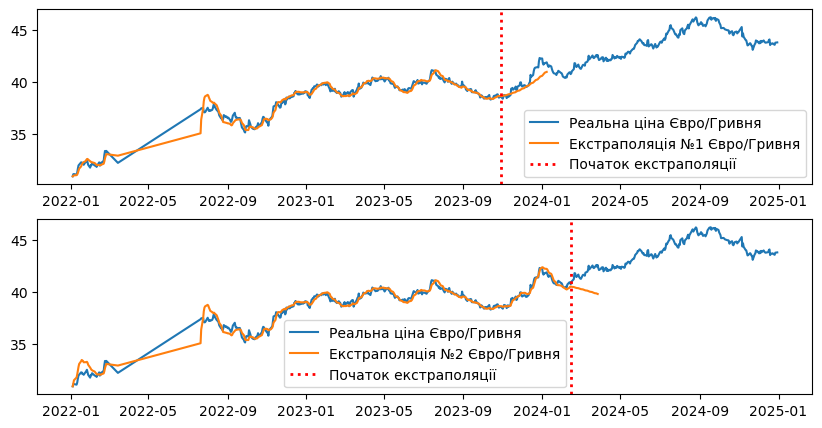

In [289]:
# Checking on how the filter has managed to "get along with" the real data
real_price_extrapolation = scaler.inverse_transform(concatenated_result.reshape(-1, 1))

fig, ax = plt.subplots(nrows=2, figsize=(10, 5))
ax[0].plot(df_full['Date'], df_full['Buy'], label='Реальна ціна Євро/Гривня')
ax[0].plot(df_full['Date'][:len(real_price_extrapolation)], real_price_extrapolation, label='Екстраполяція №1 Євро/Гривня')
ax[0].axvline(x=norm_df['Date'].iloc[-1], color='red', linestyle=':', linewidth=2, label='Початок екстраполяції')
ax[0].plot()
ax[0].legend()

norm_df_1 = df_1.copy().drop('Sell', axis=1)
norm_df_1[['Buy']] = scaler.transform(df_1[['Buy']])
filter_2 = AlphaBetaGammaFilter(alpha=0.4, beta=0.1, gamma=0.003,
                 initial_value=None, initial_velocity=0.1, initial_accel=0.05,
                 adaptive=True)

concatenated_result_1 = main_filter_process(filter_2, norm_df_1, 'Buy', 30)
real_price_extrapolation_1 = scaler.inverse_transform(concatenated_result_1.reshape(-1, 1))

ax[1].plot(df_full['Date'], df_full['Buy'], label='Реальна ціна Євро/Гривня')
ax[1].plot(df_full['Date'][:len(real_price_extrapolation_1)], real_price_extrapolation_1, label='Екстраполяція №2 Євро/Гривня')
ax[1].axvline(x=norm_df_1['Date'].iloc[-1], color='red', linestyle=':', linewidth=2, label='Початок екстраполяції')
ax[1].legend()
plt.plot();

In [271]:
print(len(norm_df), len(norm_df_1))

372 452
